# Downloading the ICECAP airborne magnetic survey to use in the notebooks
This is the reprocessed dataset from [Aitken and Ramos 2019](https://doi.org/10.26179/5e015bb8dce7f), which corresponds to the paper [Aitken et al. 2020](https://doi.org/10.1029/2020JB019825)

In [1]:
# %load_ext autoreload
# %autoreload 2

import pandas as pd
import pooch
import seaborn as sns

import airbornegeo

sns.set_style("whitegrid")

## Load data

In [2]:
import pathlib
import shutil


def preprocessing(fname, action, _pooch2):
    fname = pathlib.Path(fname)

    # Copy to the file to ***_on_data.txt
    fname_processed = fname.with_stem(fname.stem + "_only_data")
    shutil.copy(fname, fname_processed)

    # Only recalculate if new download or the processed file doesn't exist yet
    if action in ("download", "update") or not fname_processed.exists():
        line_types = ["Line", "Tie", "Special", "Random"]  # types of line permitted

        def cutlines(file, LINE):
            list = []
            with pathlib.Path.open(file) as f:
                next(f)  # skip header row
                for _i, line in enumerate(f):
                    if LINE[0] not in line:  # noqa: SIM102
                        if LINE[1] not in line:  # noqa: SIM102
                            if LINE[2] not in line:  # noqa: SIM102
                                if LINE[3] not in line:
                                    list.append(line)
            return list

        line_list = cutlines(fname, line_types)

        with pathlib.Path.open(fname_processed) as fo:
            for i in range(len(line_list)):
                fo.write("%s", line_list[i])

    return str(fname_processed)


path = pooch.retrieve(
    url="https://data.aad.gov.au/eds/api/dataset/00c5e647-ba35-4073-992b-f98ceaee6887/object/download?prefix=AAS_4460_Reprocessed_ICECAP_Magnetic_Data%2FDistribution%2FICECAP_IandII_TMI_100m_A2000.txt",
    fname="ICECAP_IandII_TMI_100m_A2000.txt",
    path=f"{pooch.os_cache('airbornegeo')}",
    known_hash="97d220b179049a0ed3abc8e348bab3cb3a48ab4a4d56dd2ffa7ed3836f649eae",
    progressbar=True,
    processor=preprocessing,
)
path

'/home/sungw937/.cache/airbornegeo/ICECAP_IandII_TMI_100m_A2000_only_data.txt'

In [3]:
data_df = pd.read_csv(
    path,
    sep=r"\s+",  # split on whitespace
    skiprows=2,  # skip the first rows which contains column names
    # nrows=1000e3,
    na_values=["*"],  # replace -9999.0 with NaN
    names=[
        "line_id",
        "fid",
        "year",
        "doy",
        "sod",
        "decimal_days",
        "longitude",
        "latitude",
        "x_admap",
        "y_admap",
        "line_distance",
        "elevation",
        "surface_elevation",
        "bed_elevation",
        "igrf_f",
        "igrf_i",
        "igrf_d",
        "tmi_raw",
        "despike_correction",
        "tmi_despiked",
        "pomme_f",
        "pomme_f_t0",
        "tmi_pomme_corrected",
        "base_correction",
        "tmi_base_corrected",
        "a2000_elevation",
        "a2000_tmi",
        "median_levelling_correction",
        "tmi_a2000_levelled",
        "tensioned_spline_correction",
        "tmi_tensioned_spline_corrected",
    ],
)
data_df

,line_id,fid,year,doy,sod,decimal_days,longitude,latitude,x_admap,y_admap,...,pomme_f_t0,tmi_pomme_corrected,base_correction,tmi_base_corrected,a2000_elevation,a2000_tmi,median_levelling_correction,tmi_a2000_levelled,tensioned_spline_correction,tmi_tensioned_spline_corrected
0,ASB_JKB0a_R16Ta.1,0,2009.0,26.0,63240.30,3313.731948,96.154742,-74.379667,1745030.71,-188176.46,...,58787.75,-18.38,0.21,-18.58,NaN,NaN,NaN,NaN,NaN,NaN
1,ASB_JKB0a_R16Ta.1,100,2009.0,26.0,63241.35,3313.731960,96.151627,-74.379405,1745070.64,-188084.77,...,58787.36,-11.65,0.20,-11.85,2020.03,-21.21,0.00,-21.21,-67.25,-88.46
2,ASB_JKB0a_R16Ta.1,200,2009.0,26.0,63242.40,3313.731972,96.148500,-74.379152,1745109.44,-187992.61,...,58786.87,-5.45,0.19,-5.64,2020.03,-3.20,0.00,-3.20,-67.25,-70.45
3,ASB_JKB0a_R16Ta.1,300,2009.0,26.0,63243.45,3313.731984,96.145365,-74.378907,1745147.40,-187900.10,...,58786.35,0.00,0.18,-0.17,2020.03,13.57,0.00,13.57,-67.25,-53.68
4,ASB_JKB0a_R16Ta.1,400,2009.0,26.0,63244.50,3313.731997,96.142225,-74.378667,1745184.88,-187807.39,...,58785.80,4.40,0.17,4.24,2020.03,28.90,0.00,28.90,-67.25,-38.35
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2035267,WSB_JKB2h_R39b_magfld.1,44000,2012.0,319.0,3729.60,4701.043167,123.397372,-75.145177,1392714.89,-918234.63,...,62671.43,22.74,38.32,-15.58,2018.19,13.14,31.34,44.47,1.57,46.04
2035268,WSB_JKB2h_R39b_magfld.1,44100,2012.0,319.0,3730.84,4701.043181,123.395690,-75.144409,1392814.63,-918241.74,...,62671.65,23.58,38.32,-14.73,2018.19,13.59,31.34,44.93,1.57,46.50
2035269,WSB_JKB2h_R39b_magfld.1,44200,2012.0,319.0,3732.09,4701.043196,123.394014,-75.143640,1392914.36,-918249.03,...,62671.87,24.44,38.31,-13.87,NaN,NaN,NaN,NaN,NaN,NaN
2035270,WSB_JKB2h_R39b_magfld.1,44300,2012.0,319.0,3733.35,4701.043210,123.392345,-75.142871,1393014.07,-918256.55,...,62672.10,25.00,38.31,-13.31,NaN,NaN,NaN,NaN,NaN,NaN


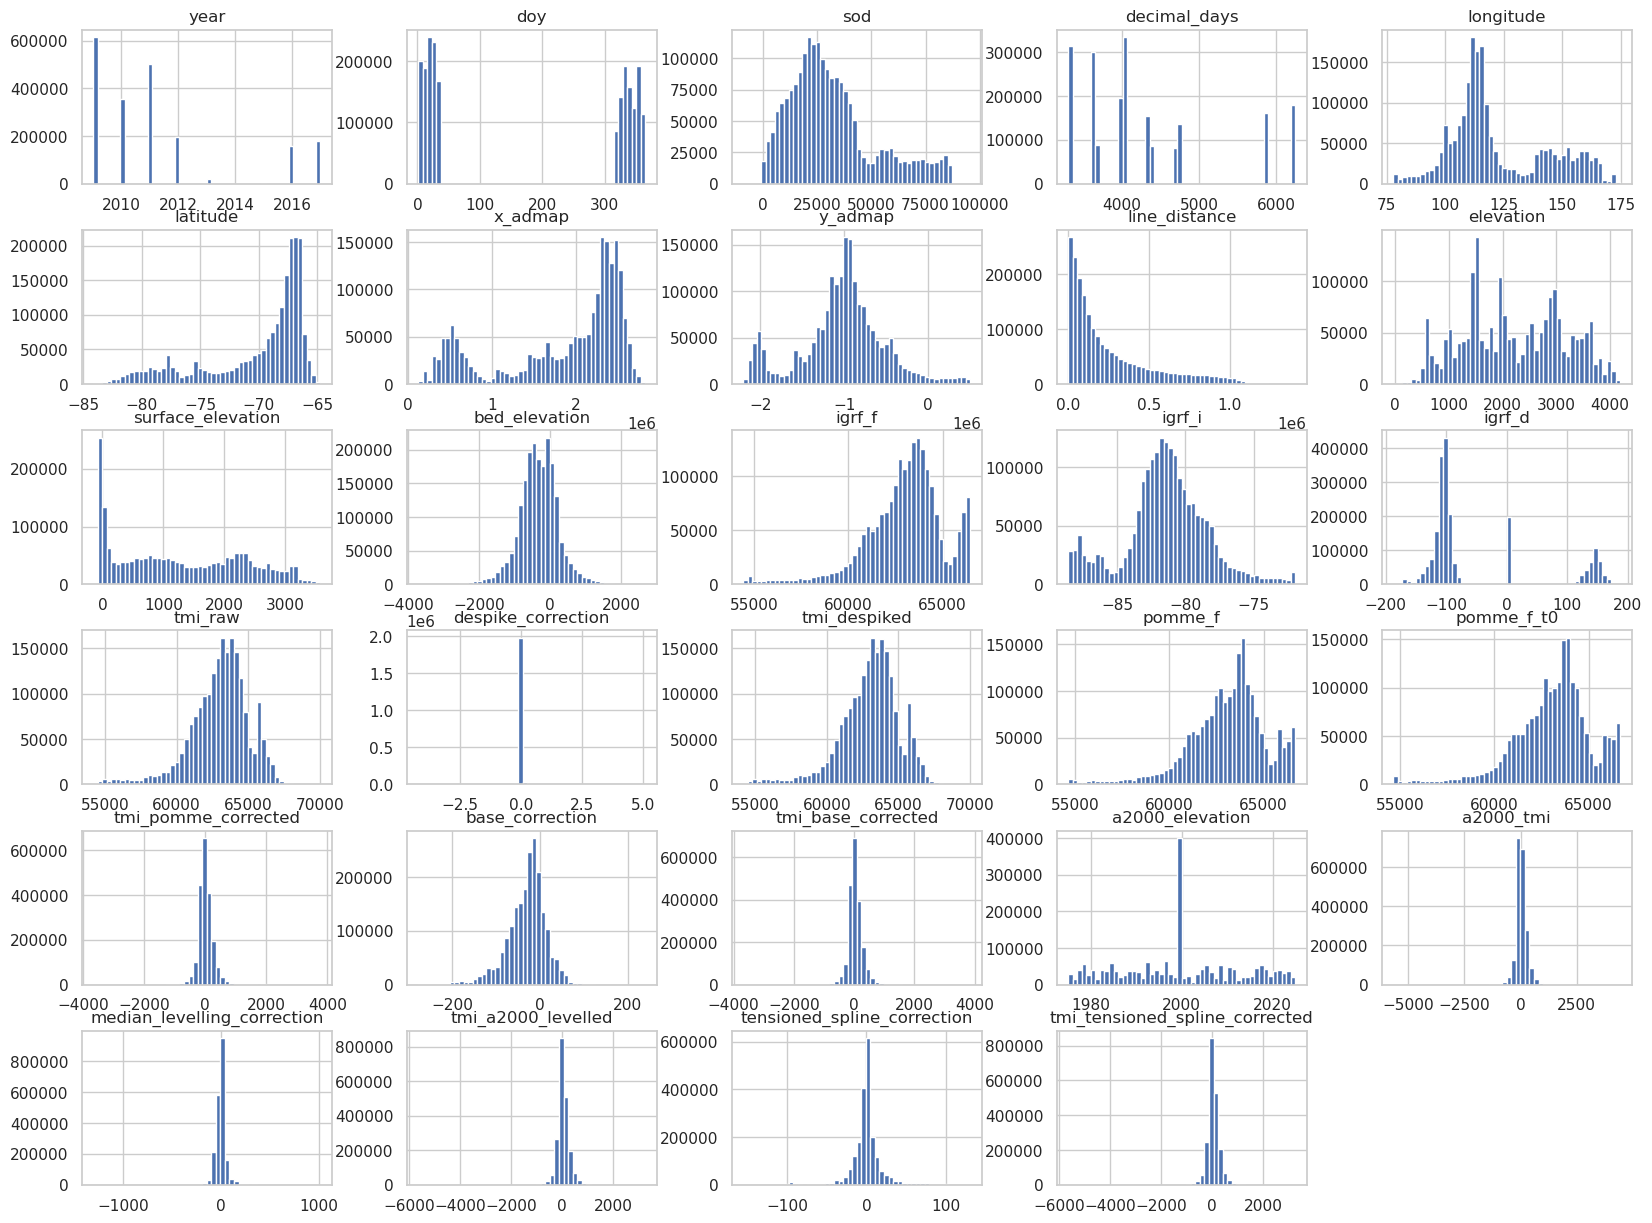

In [4]:
data_df.hist(bins=50, figsize=(20, 15));

In [ ]:
# reproject to EPSG:3031 Polar Stereographic
data_df["easting"], data_df["northing"] = airbornegeo.reproject(
    data_df.longitude,
    data_df.latitude,
    input_crs="EPSG:4326",
    output_crs="EPSG:3031",
)
data_df

In [6]:
data_df.describe()

,year,doy,sod,decimal_days,longitude,latitude,x_admap,y_admap,line_distance,elevation,...,base_correction,tmi_base_corrected,a2000_elevation,a2000_tmi,median_levelling_correction,tmi_a2000_levelled,tensioned_spline_correction,tmi_tensioned_spline_corrected,easting,northing
count,2.033109e+06,2.033109e+06,2.033109e+06,2.033109e+06,2.033109e+06,2.033109e+06,2.033109e+06,2.033109e+06,2.033109e+06,2.033109e+06,...,2.033054e+06,2.033035e+06,2.031121e+06,2.030974e+06,2.030839e+06,2.030839e+06,2.030839e+06,2.030839e+06,2.033109e+06,2.033109e+06
mean,2.011264e+03,1.780806e+02,3.167995e+04,4.291931e+03,1.224337e+02,-7.024648e+01,1.843696e+06,-1.021042e+06,2.584102e+05,2.214694e+03,...,-3.099534e+01,3.931846e+01,1.999788e+03,3.731678e+01,-1.788569e+00,3.554183e+01,-1.697305e-01,3.537211e+01,1.793490e+06,-9.932379e+05
std,2.570041e+00,1.611675e+02,2.018982e+04,8.943363e+02,2.117820e+01,4.492817e+00,7.398809e+05,5.000740e+05,2.703552e+05,9.399281e+02,...,4.574396e+01,2.629324e+02,1.307855e+01,2.589660e+02,5.991359e+01,2.522648e+02,1.977529e+01,2.522225e+02,7.197332e+05,4.864564e+05
min,2.009000e+03,1.000000e+00,-9.294290e+03,3.298607e+03,7.762933e+01,-8.416519e+01,1.244714e+05,-2.204780e+06,0.000000e+00,-4.287000e+01,...,-2.770500e+02,-3.684830e+03,1.975030e+03,-5.663940e+03,-1.305230e+03,-5.641570e+03,-1.557100e+02,-5.646760e+03,1.210819e+05,-2.144742e+06
25%,2.009000e+03,2.000000e+01,1.754473e+04,3.640523e+03,1.089891e+02,-7.228444e+01,1.456651e+06,-1.248410e+06,5.740000e+04,1.479870e+03,...,-5.477000e+01,-8.809000e+01,1.989620e+03,-9.036000e+01,-2.109000e+01,-8.802000e+01,-6.010000e+00,-8.794000e+01,1.416985e+06,-1.214415e+06
50%,2.011000e+03,3.700000e+01,2.726331e+04,4.021447e+03,1.152084e+02,-6.818261e+01,2.182220e+06,-9.886312e+05,1.494000e+05,2.112060e+03,...,-2.458000e+01,8.610000e+00,2.000000e+03,8.900000e+00,0.000000e+00,8.100000e+00,-1.900000e-01,8.480000e+00,2.122796e+06,-9.617098e+05
75%,2.012000e+03,3.370000e+02,4.020095e+04,4.710049e+03,1.407825e+02,-6.698804e+01,2.408385e+06,-7.566044e+05,3.757000e+05,2.966650e+03,...,-3.760000e+00,1.490500e+02,2.009230e+03,1.518500e+02,1.990000e+01,1.459000e+02,5.215000e+00,1.456200e+02,2.342802e+06,-7.360014e+05
max,2.017000e+03,3.650000e+02,9.570950e+04,6.245363e+03,1.749176e+02,-6.473134e+01,2.826609e+06,5.012924e+05,1.404500e+06,4.198810e+03,...,2.394800e+02,3.859790e+03,2.025000e+03,4.433030e+03,1.016240e+03,3.258350e+03,1.310600e+02,3.249710e+03,2.749638e+06,4.876417e+05


In [ ]:
data_df["line"] = data_df["line_id"]
survey = airbornegeo.Survey(data_df, line_column="line")
survey.unique_line_id()
data_df = survey.data
data_df.line.unique()

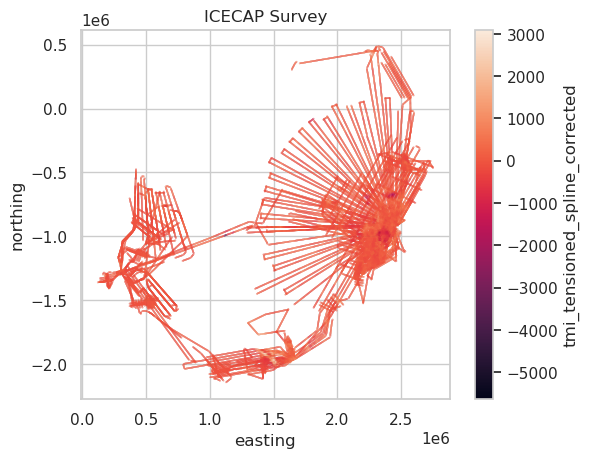

In [8]:
ax = data_df[::10].plot.scatter(
    "easting",
    "northing",
    c="tmi_tensioned_spline_corrected",
    s=0.002,
    title="ICECAP Survey",
)
ax.set_aspect("equal")

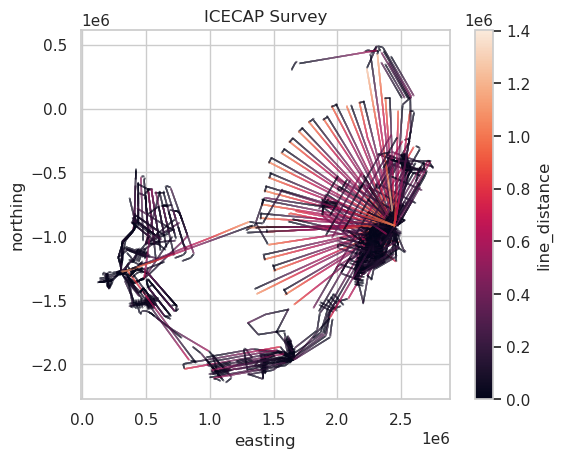

In [9]:
ax = data_df[::10].plot.scatter(
    "easting",
    "northing",
    c="line_distance",
    s=0.002,
    title="ICECAP Survey",
)
ax.set_aspect("equal")

In [12]:
data_df.to_csv("../data/ICECAP_magnetic_survey.csv", index=False)